這張圖表非常經典，它完美詮釋了長期投資中**「時間的複利效應」**與**「沉澱成本」**的概念。

我們可以從以下幾個核心觀點來深度解析這張圖表所傳達的理財智慧：

## 核心觀點解析

### 1. 時間是複利最強大的放大鏡
誠如你所提到的，2009 年投入的 1 元，到 2022 年已經增值到 5.17 元（漲幅超過 400%）。這是因為越早投入市場的資金，經歷了越長期的配股配息與指數成長。

* **資產留在市場裡的時間越長，複利能滾動的次數就越多。**
* 最終才會形成圖表左側那座驚人的「資產高山」。

### 2. 為什麼越晚投入的成長性越低？
圖表曲線一路向右下滑，甚至到 2021~2022 年附近逼近黃色的 1 元基準線（甚至短暫跌破）。這並不是說後來的台股表現不好，而是**因為「距離統計終點的時間太短了」**：

* **時間發酵不足**：2021 年投入的 1 元，到 2022 年底只有 1 年左右的時間，加上 2022 年適逢台股大盤修正，因此短線報酬看起來很低、甚至微幅虧損。
* **關鍵結論**：再好的投資工具，如果沒有給它足夠的時間，也無法展現魔力。

### 3. 定期定額的「微笑曲線」本質
如果我們把這張圖的每一天相加，就是我們常說的「定期定額（DCA）」。

| 部位區塊 | 代表意義 | 現實狀態 |
| :--- | :--- | :--- |
| **左邊的區塊 (早期資金)** | 累積的「核心部位」 | 已經長成大樹，提供穩固的獲利基礎。 |
| **右邊的區塊 (近期資金)** | 剛投入的「新資金」 | 雖然目前看起來還沒長大，但它們正在經歷扎根階段。 |

---

> 💡 **核心總結**
>
> 這張圖給投資人最大的啟示是：**「種一棵樹最好的時間是十年前，其次是現在。」** 
> 
> 我們無法回到 2009 年去投下那高回報的 1 元，但如果我們此時此刻不開始投入，到了未來，我們又會看著現在的低點扼腕。投資不需要追求神準的「擇時」，只要開始「拉長時間」，時間自然會幫你把 1 元變成 5 元。

In [4]:
pip install yfinance matplotlib pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# =========================================================
# 步驟 1：下載並設定字型（直接指定檔案路徑，保證成功）
# =========================================================
font_url = "https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf"
font_path = "SourceHanSerifTW-VF.ttf"

if not os.path.exists(font_path):
    print("正在下載中文字型...")
    os.system(f"wget -O {font_path} {font_url}")

# 建立字型物件
tw_font = FontProperties(fname=font_path)
plt.rcParams["axes.unicode_minus"] = False  # 正常顯示負號

[*********************100%***********************]  1 of 1 completed

正在下載台股數據...



/tmp/ipykernel_3179/4073522738.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["${:,.0f}".format(x) for x in ax.get_yticks()])


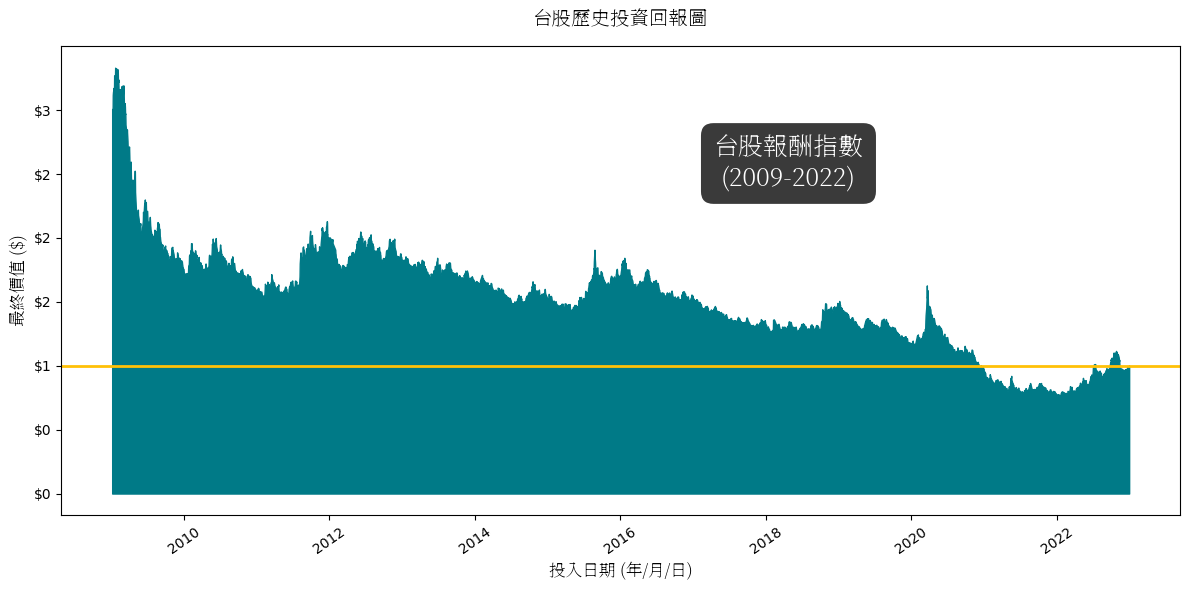

In [13]:
import yfinance as yf
import pandas as pd

# 補上這行，解決 NameError 錯誤！
import matplotlib.ticker as mticker

# =========================================================
# 步驟 2：下載台股數據（自動到最新日期）
# =========================================================
ticker = "^TWII"
start_date = "2009-01-05"
end_date = "2022-12-31"

print("正在下載台股數據...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
# df = yf.download(ticker, start=start_date, auto_adjust=True)


# 處理 MultiIndex 欄位結構
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Close"]].dropna()

# 計算核心邏輯
final_price = float(df["Close"].iloc[-1])
df["Growth_of_1$"] = final_price / df["Close"]

# =========================================================
# 步驟 3：繪圖
# =========================================================
plt.figure(figsize=(12, 6), dpi=100)

# 畫出面積圖 (對應原圖的深青色)
plt.fill_between(
    df.index,
    df["Growth_of_1$"],
    color="#007A87",
    alpha=1.0,
    label="Value of $1 invested",
)

# 畫出 1 元基準線 (黃色線)
plt.axhline(y=1.0, color="#FFC107", linestyle="-", linewidth=2)

# ---- 重點：重現原圖的「深灰色動態文字方塊」 ----
# 自動取得資料庫最後一筆資料的年份
latest_year = df.index[-1].year
box_text = f"台股報酬指數\n(2009-{latest_year})"

# 設定文字方塊樣式 (深灰色、微圓角、無邊框)
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="#3A3A3A", edgecolor="none")

# 將文字方塊畫在圖表相對位置 (x=0.65, y=0.75 差不多在右上方)
plt.text(
    0.65,
    0.75,
    box_text,
    transform=plt.gca().transAxes,
    color="white",
    fontsize=18,
    fontweight="bold",
    fontproperties=tw_font,
    ha="center",
    va="center",
    bbox=bbox_props,
)
# ----------------------------------------------

# 基本標題與標籤設定
plt.title("台股歷史投資回報圖", fontproperties=tw_font, fontsize=14, pad=15)
plt.ylabel("最終價值 ($)", fontproperties=tw_font, fontsize=12)
plt.xlabel("投入日期 (年/月/日)", fontproperties=tw_font, fontsize=12)

# 設定 Y 軸格式
ax = plt.gca()
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.set_yticklabels(["${:,.0f}".format(x) for x in ax.get_yticks()])

plt.xticks(rotation=35)
plt.tight_layout()
plt.show()